In [5]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset de Energía
df_energia = pd.read_csv('energia_data.csv')

print("=== FASE DE LIMPIEZA Y PREPARACIÓN: ENERGÍA ===")
print(f"Total de registros iniciales: {len(df_energia)}")

# 2. Verificar nulos y duplicados
nulos_e = df_energia.isnull().sum().sum()
duplicados_e = df_energia.duplicated().sum()
print(f"Valores nulos: {nulos_e}")
print(f"Registros duplicados: {duplicados_e}")

# 3. Auditoría y Exclusión de Outliers por IQR
print("\nAuditoría y Filtrado de Outliers:")
cols_e = ['Temperatura', 'Hora', 'Dia_Semana', 'Consumo_Energia']
mask_e = pd.Series(True, index=df_energia.index)

for col in cols_e:
    Q1 = df_energia[col].quantile(0.25)
    Q3 = df_energia[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers_cnt = ((df_energia[col] < lim_inf) | (df_energia[col] > lim_sup)).sum()
    print(f"   - Variable '{col}': {outliers_cnt} atípicos fuera de [{lim_inf:.2f}, {lim_sup:.2f}]")
    mask_e &= (df_energia[col] >= lim_inf) & (df_energia[col] <= lim_sup)

# Aplicar exclusión formal
df_energia = df_energia[mask_e].reset_index(drop=True)
print(f"\n¡Dataset de energía depurado! Registros finales limpios: {len(df_energia)}")

=== FASE DE LIMPIEZA Y PREPARACIÓN: ENERGÍA ===
Total de registros iniciales: 10000
Valores nulos: 0
Registros duplicados: 0

Auditoría y Filtrado de Outliers:
   - Variable 'Temperatura': 90 atípicos fuera de [11.48, 38.41]
   - Variable 'Hora': 0 atípicos fuera de [-12.00, 36.00]
   - Variable 'Dia_Semana': 0 atípicos fuera de [-4.00, 12.00]
   - Variable 'Consumo_Energia': 66 atípicos fuera de [227.14, 572.73]

¡Dataset de energía depurado! Registros finales limpios: 9867


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Separar variables independientes (X) y dependiente (y)
X_e = df_energia[['Temperatura', 'Hora', 'Dia_Semana']]
y_e = df_energia['Consumo_Energia']

# 2. Dividir en entrenamiento (80%) y prueba (20%)
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_e, y_e, test_size=0.2, random_state=42)

# 3. Entrenar el modelo de Regresión Lineal Múltiple
modelo_energia = LinearRegression()
modelo_energia.fit(X_train_e, y_train_e)

# 4. Predicciones y Evaluación (con RMSE y R²)
y_pred_e = modelo_energia.predict(X_test_e)
mse_e = mean_squared_error(y_test_e, y_pred_e)
rmse_e = np.sqrt(mse_e) # Raíz del Error Cuadrático Medio
r2_e = r2_score(y_test_e, y_pred_e)

print("--- RESULTADOS DEL MODELO DE CONSUMO DE ENERGÍA ---")
print(f"Intercepto (b0): {modelo_energia.intercept_:.4f}")
for col, coef in zip(X_e.columns, modelo_energia.coef_):
    print(f"Coeficiente para {col}: {coef:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_e:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_e:.4f}")

--- RESULTADOS DEL MODELO DE CONSUMO DE ENERGÍA ---
Intercepto (b0): 101.9679
Coeficiente para Temperatura: 9.9464
Coeficiente para Hora: 5.0002
Coeficiente para Dia_Semana: -3.0689
Raíz del Error Cuadrático Medio (RMSE): 19.7539
Coeficiente de Determinación (R²): 0.8954


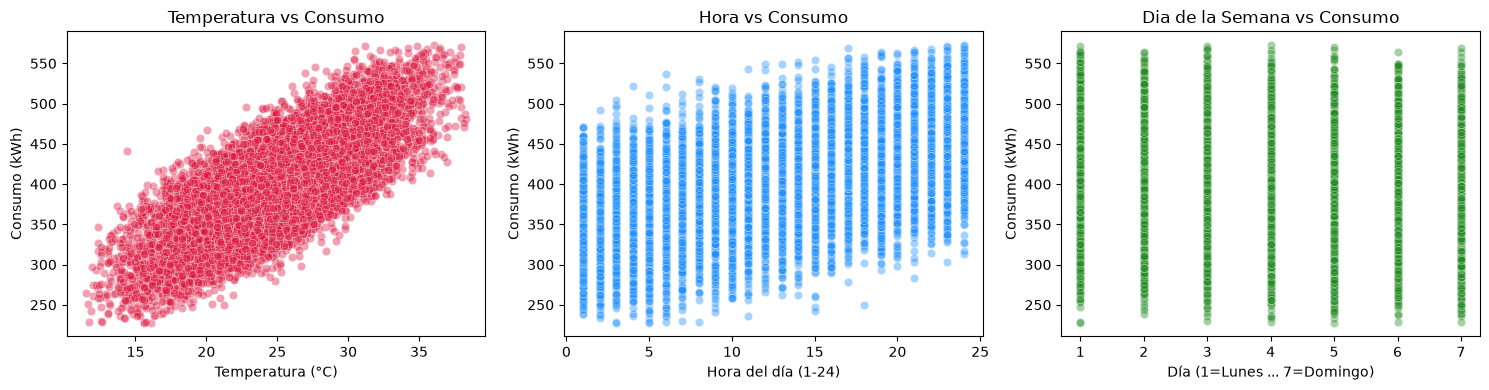

¡Modelo exportado exitosamente como 'modelo_energia.pkl'!

--- PRUEBA DE CARGA Y PREDICCIÓN (ENERGÍA) ---
Datos ingresados -> Temperatura: 25°C, Hora: 14, Día Semana: 3
Consumo de Energía predicho: 411.4243 kWh


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd

# 1. Gráficas de dispersión para visualizar relaciones
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(x=df_energia['Temperatura'], y=df_energia['Consumo_Energia'], alpha=0.4, color='crimson')
plt.title('Temperatura vs Consumo')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Consumo (kWh)')

plt.subplot(1, 3, 2)
sns.scatterplot(x=df_energia['Hora'], y=df_energia['Consumo_Energia'], alpha=0.4, color='dodgerblue')
plt.title('Hora vs Consumo')
plt.xlabel('Hora del día (1-24)')
plt.ylabel('Consumo (kWh)')

plt.subplot(1, 3, 3)
sns.scatterplot(x=df_energia['Dia_Semana'], y=df_energia['Consumo_Energia'], alpha=0.4, color='forestgreen')
plt.title('Dia de la Semana vs Consumo')
plt.xlabel('Día (1=Lunes ... 7=Domingo)')
plt.ylabel('Consumo (kWh)')

plt.tight_layout()
plt.show()

# 2. Exportar el modelo entrenado
nombre_archivo_e = 'modelo_energia.pkl'
joblib.dump(modelo_energia, nombre_archivo_e)
print(f"¡Modelo exportado exitosamente como '{nombre_archivo_e}'!")

# 3. Comprobar carga y predicción con DataFrame (sin advertencias)
modelo_e_cargado = joblib.load(nombre_archivo_e)
# Datos de prueba ficticios: Temperatura 25°C, Hora 14 (2 PM), Día de la semana 3 (Miércoles)
datos_nuevo_consumo = pd.DataFrame([[25.0, 14, 3]], columns=['Temperatura', 'Hora', 'Dia_Semana'])
pred_energia_prueba = modelo_e_cargado.predict(datos_nuevo_consumo)

print("\n--- PRUEBA DE CARGA Y PREDICCIÓN (ENERGÍA) ---")
print(f"Datos ingresados -> Temperatura: 25°C, Hora: 14, Día Semana: 3")
print(f"Consumo de Energía predicho: {pred_energia_prueba[0]:.4f} kWh")